## Power loss plot

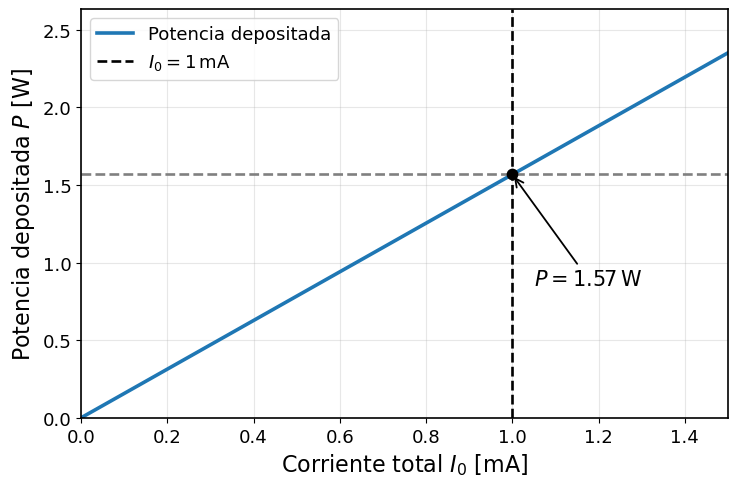

E/Q = 30.438 kV
P a I0 = 1 mA: 1.568 W
Figura guardada en: beam_plots/potencia_colimadores_vs_corriente.pdf


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Potencia depositada en colimadores frente a corriente total
# ============================================================

OUTDIR = Path("beam_plots")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# Estilo de figura
# -----------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.linewidth": 1.2,
})

# -----------------------------
# Parámetros físicos
# -----------------------------
E_MeV = 0.182629   # energía cinética por ion [MeV]
Q_ion = 6          # carga del ion 12C6+
T = 94.85          # transmisión [%]

# E/Q en voltios
# 1 MeV/e = 1 MV  ->  E[MeV]/Q = MV
E_over_Q_V = (E_MeV / Q_ion) * 1e6   # [V]

# -----------------------------
# Rango de corriente total
# -----------------------------
I_mA = np.linspace(0.001, 1.5, 500)   # [mA]
I_A = I_mA * 1e-3                     # [A]

# -----------------------------
# Potencia perdida
# -----------------------------
loss_fraction = 1.0 - T / 100.0
I_loss = I_A * loss_fraction
P = I_loss * E_over_Q_V               # [W]

# Punto de referencia a 1 mA
I_ref_mA = 1.0
I_ref_A = I_ref_mA * 1e-3
P_ref = I_ref_A * loss_fraction * E_over_Q_V

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.1))

ax.plot(
    I_mA,
    P,
    linewidth=2.6,
    label="Potencia depositada"
)

ax.axvline(
    I_ref_mA,
    linestyle="--",
    linewidth=1.9,
    color="black",
    label=rf"$I_0 = {I_ref_mA:.0f}\,\mathrm{{mA}}$"
)

ax.axhline(
    P_ref,
    linestyle="--",
    linewidth=1.9,
    color="gray"
)

ax.scatter(
    [I_ref_mA],
    [P_ref],
    s=55,
    color="black",
    zorder=5
)

ax.annotate(
    rf"$P = {P_ref:.2f}\,\mathrm{{W}}$",
    xy=(I_ref_mA, P_ref),
    xycoords="data",
    xytext=(0.70, 0.34),
    textcoords="axes fraction",
    fontsize=15,
    ha="left",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.3)
)

ax.set_xlabel(r"Corriente total $I_0$ [mA]")
ax.set_ylabel(r"Potencia depositada $P$ [W]")

ax.set_xlim(0, 1.5)
ax.set_ylim(0, max(P.max(), P_ref) * 1.12)

ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

plt.tight_layout()

output_path = OUTDIR / "potencia_colimadores_vs_corriente.pdf"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

print(f"E/Q = {E_over_Q_V/1e3:.3f} kV")
print(f"P a I0 = 1 mA: {P_ref:.3f} W")
print(f"Figura guardada en: {output_path}")